In [1]:
from ocpa.objects.log.importer.ocel import factory as ocel_import_factory
from ocpa.visualization.log.variants import factory as variants_visualization_factory

import Super_Variant_Definition as SVD
import Super_Variant_Hierarchy as SVH
import Super_Variant_Visualization as SVV
import Intra_Variant_Generation as IAVG
import Intra_Variant_Summarization as IAVS
import Summarization_Selection as IASS
import Inter_Variant_Generation as IEVG
import Inter_Variant_Summarization as IEVS
import Input_Extraction_Definition as IED
import Inter_Lane_Summarization as ILS
import Inter_Lane_Alignment as ILA

from Evaluation.templates import (build_triad_hierarchy, print_hierarchy_costs)
from config import P2P_LOG, TEST_LOGS_3, BPI_2017_TOP10_LOG

VISUALIZE_INTERMEDIATE_RESULTS = False

In [2]:
# EVALUATION Settings
ILA.ALIGN = False
filename = P2P_LOG

# Import Log
ocel = ocel_import_factory.apply(file_path=filename)

## Intra-Variant Summarization

In [3]:
### FUNCTION IED.get_unique_summarizations_from_process()
from ocpa.visualization.log.variants import factory as variants_visualization_factory

# -> Division into discrete steps already happens here, viz package part of process discovery in ocpa
# {Activity: [start index, end index], [other appearances / intersections]}
variant_layout = variants_visualization_factory.apply(ocel)
print("Base Variants from ocel:\n", variant_layout, "\n\n\n")
variants = []

# Actually iterated over all variants
sample_variant = 0

# Extract lanes from variant
extracted_variant = IED.extract_lanes(variant_layout[ocel.variants[sample_variant]], ocel.variant_frequencies[sample_variant])
variants.append(extracted_variant)
print("Extracted Variant:\n", extracted_variant, "\n\n\n")

# summarize the variant, then added to all_summarizations
extracted_summarizations = IAVS.within_variant_summarization(extracted_variant, print_results=False)
sample_summarization = extracted_summarizations[0]
# sample_summarization added to list of all summarizations
print("Extracted Summarization:\n", sample_summarization, "\n\n\n")

encoding = sample_summarization.encode_lexicographically()
# encoding used as key in dict to store all unique summarizations
# as values, add for index 0 the variant number and for index 1 the summarization 
# -> {encoding: {0: [variant_number], 1: [summarization]}}
# encoding used als key in set to store all unique summarizations 
# -> {(encoding, [summarization])}
print("Encoding:\n", encoding, "\n\n\n")

### FUNCTION IAVG.complete_intra_variant_summarization_from_process
# BAD SCALABILITY this line
universe, summ_dict = IAVG.get_unique_summarizations_from_process(ocel, print_results=True)
# Sorts the unique summarizations into subsets based on the variants that they summarize.
all_summ, summ_per_variant = IAVG.__determine_subsets(universe, summ_dict)
print("All Summarizations:\n", all_summ[0], "\n")
print("Per Variant Dict:\n", summ_per_variant[0], "\n")
print("Per Encoding Dict:\n", summ_dict, "\n\n\n")





# Generate and select intra-variant summarizations
all_summarizations, per_variant_dict, per_encoding_dict = IAVG.complete_intra_variant_summarization_from_process(ocel, print_results=False)

intra_variant_summarizations = IASS.intra_variant_summarization_selection(all_summarizations, per_variant_dict, per_encoding_dict)
print("Intra Variant Summarizations:\n", intra_variant_summarizations[0], "\n\n\n")

try:
    # EVALUATION Settings
    # Cleansing with actual frequencies
    global_frequencies = [0.069, 0.05, 0.047, 0.03, 0.025, 0.019, 0.019, 0.018, 0.017, 0.016]
    for i in range(len(intra_variant_summarizations)):
        intra_variant_summarizations[i].frequency = global_frequencies[i]
    
    # Visualize selected intra-variant summarizations
    if VISUALIZE_INTERMEDIATE_RESULTS:
        for i in range(len(intra_variant_summarizations)):
            SVV.visualize_super_variant(intra_variant_summarizations[i])
    
    if VISUALIZE_INTERMEDIATE_RESULTS:
        # Visualize intra-variant summarizations of variant v_3
        SVV.MARK_INCORRECT_INTERACTIONS = False
        SVV.visualize_variant(all_summarizations[3][1][1][0],3)
        SVV.visualize_variant(all_summarizations[4][1][1][0],3)
        SVV.MARK_INCORRECT_INTERACTIONS = True
except:
    for x in intra_variant_summarizations:
        print(x)

Base Variants from ocel:
 {'667bf359540fe253fd88978b0570f5a0': ([['Create Invoice Receipt', [[15, 15], [4, 0]]], ['Create Goods Receipt', [[24, 24], [10, 1]]], ['Create Invoice Receipt', [[16, 16], [4, 2]]], ['Create Purchase Order', [[8, 8], [11, 15]]], ['Create Goods Receipt', [[10, 10], [12, 2]]], ['Perform Two-Way Match', [[17, 17], [4, 2]]], ['Perform Two-Way Match', [[18, 18], [4, 0]]], ['Create Purchase Order', [[3, 3], [13, 15]]], ['Create Goods Receipt', [[13, 15], [11, 2]]], ['Approve Purchase Order', [[10, 10], [11, 15]]], ['Create Purchase Order', [[5, 5], [10, 15]]], ['Create Goods Receipt', [[7, 10], [10, 0]]], ['Create Invoice Receipt', [[19, 19], [4, 1]]], ['Create Invoice Receipt', [[20, 20], [4, 3]]], ['Approve Purchase Order', [[9, 9], [12, 15]]], ['Create Goods Receipt', [[11, 11], [10, 2]]], ['Perform Two-Way Match', [[21, 21], [4, 1]]], ['Create Goods Receipt', [[12, 12], [13, 2]]], ['Perform Two-Way Match', [[22, 22], [4, 3]]], ['Create Goods Receipt', [[14, 14],

  0%|          | 0/315 [00:00<?, ?it/s]

 
Summarizing variant 0 of the process...
------------------------------------------
Current Level: 1
----
Summarizing Lanes: [0]

Adding the common activity: Create Goods Receipt
This is an interaction point: True

Adding the common activity: Create Invoice Receipt
This is an interaction point: True

Adding the common activity: Perform Two-Way Match
This is an interaction point: True

Adding the common activity: Execute Payment
This is an interaction point: True
------------------------------------------
Current Level: 2
----
Summarizing Lanes: [1]

Adding the common activity: Create Invoice Receipt
This is an interaction point: True

Adding the common activity: Perform Two-Way Match
This is an interaction point: True

Adding the common activity: Execute Payment
This is an interaction point: True
------------------------------------------
Current Level: 3
----
Summarizing Lanes: [2]

Adding the common activity: Create Purchase Requisition
This is an interaction point: True

Adding the

  0%|          | 0/315 [00:00<?, ?it/s]

 
Summarizing variant 0 of the process...
 
Summarizing variant 1 of the process...
 
Summarizing variant 2 of the process...
 
Summarizing variant 3 of the process...
 
Summarizing variant 4 of the process...
 
Summarizing variant 5 of the process...
Could not summarize variant 5.
 
Summarizing variant 6 of the process...
Could not summarize variant 6.
 
Summarizing variant 7 of the process...
 
Summarizing variant 8 of the process...
Could not summarize variant 8.
 
Summarizing variant 9 of the process...
 
Summarizing variant 10 of the process...
Could not summarize variant 10.
 
Summarizing variant 11 of the process...
 
Summarizing variant 12 of the process...
Could not summarize variant 12.
 
Summarizing variant 13 of the process...
Could not summarize variant 13.
 
Summarizing variant 14 of the process...
Could not summarize variant 14.
 
Summarizing variant 15 of the process...
Could not summarize variant 15.
 
Summarizing variant 16 of the process...
Could not summarize varian

INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23



 Objective value: 15


 Variable values: 

0: 1.0
1: 1.0
2: 1.0
3: 1.0
4: 1.0
5: 1.0
6: 1.0
7: 1.0
8: 1.0
9: 1.0
10: 1.0
11: 1.0
12: 1.0
13: 1.0
14: 1.0
-----------------------------
15/15unique summarizations have been selected for the Between-Lane Summarization.
Intra Variant Summarizations:
 Super Variant (0,)
Lanes: 
ID: (0,), Name: goods receipt 0, Cardinality: 1:  [(Pos B(0, 7): Interaction Create Goods Receipt),(Pos B(0, 8): Interaction Create Invoice Receipt),(Pos B(0, 9): Interaction Perform Two-Way Match),(Pos B(0, 10): Interaction Execute Payment)]
ID: (1,), Name: invoice receipt 0, Cardinality: 1:  [(Pos B(0, 8): Interaction Create Invoice Receipt),(Pos B(0, 9): Interaction Perform Two-Way Match),(Pos B(0, 10): Interaction Execute Payment)]
ID: (2,), Name: material 0, Cardinality: 1:  [(Pos B(0, 0): Interaction Create Purchase Requisition),(Pos B(0, 1): Interaction Approve Purchase Requisition)]
ID: (3,), Name: payment 0, Cardinality: 1:  [(Pos B(0, 10): Interaction Execut

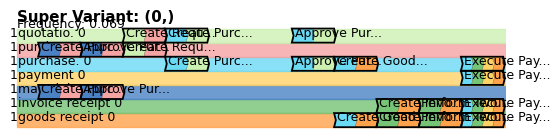

Super Variant Number:  3
Super Variant String:
 goods receipt 0: CAR 1: IP[7:7, Create Goods Receipt] IP[8:8, Create Invoice Receipt] IP[9:9, Perform Two-Way Match] IP[10:10, Execute Payment] invoice receipt 0: CAR 1: IP[8:8, Create Invoice Receipt] IP[9:9, Perform Two-Way Match] IP[10:10, Execute Payment] material 0: CAR 1: IP[0:0, Create Purchase Requisition] IP[1:1, Delegate Purchase Requisition Approval] payment 0: CAR 1: IP[10:10, Execute Payment] purchase_order 0: CAR 1: IP[3:3, Create Purchase Order] IP[6:6, Approve Purchase Order] IP[7:7, Create Goods Receipt] IP[10:10, Execute Payment] purchase_requisition 0: CAR 1: IP[0:0, Create Purchase Requisition] IP[1:1, Delegate Purchase Requisition Approval] IP[2:2, Create Request for Quotation] quotation 0: CAR 1: IP[2:2, Create Request for Quotation] IP[3:3, Create Purchase Order] IP[6:6, Approve Purchase Order] - IP[0,[material 0, purchase_requisition 0]] IP[1,[material 0, purchase_requisition 0]] IP[10,[goods receipt 0, invoice rec

In [4]:
first = all_summarizations[3]
SVV.visualize_super_variant(intra_variant_summarizations[0])

superVarNr = first[0]
superVarStr = first[1][0]
superVarRef = first[1][1]

print("Super Variant Number: ", superVarNr)
print("Super Variant String:\n", superVarStr)

@SuperLane.encode_lexicographically()

a 0 -> Lane a, instance 0

CAR 1 -> Lane instance is executed exactly once

Constructs: -> [startIndex:EndIndex]
- IP = Interaction Point
- CO = CommonConstruct / "Plain Activity"
- CH = ChoiceConstruct
- OP = OptionalConstruct

# Inter-Variant Summarization

Evaluating the decision of matching lane (4,) of Super Variant 1 with the lane (3,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (1,) of Super Variant 1 with the lane (1,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (0,) of Super Variant 1 with the lane (0,) of Super Variant 2.
Propagating.
Propagating the last decision among [] and [].
Empty. The rest is optional.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (4,) of Super Variant 1 with the lane (5,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (1,) of Super Variant 1 with the lane (1,) of Super Variant 2.
Not propagating.
This is

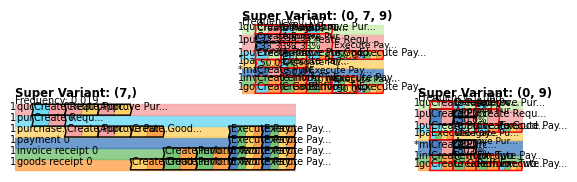

Interaction not found.
Interaction not found.
Interaction not found.


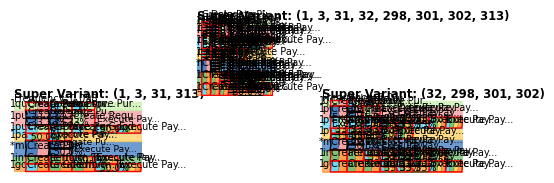

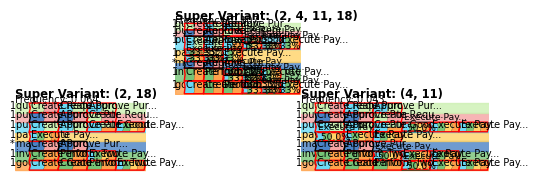

Cost for hierarchy 0: 48


In [5]:
# MODE 1 - Frequency Distribution and No Nested Structures
IEVG.NESTED_STRUCTURES = False
initial_super_variants = intra_variant_summarizations

# Generating 3 hierarchies from the initial super variants with uniform frequency distribution
hierarchies, final_super_variants = IEVG.generate_super_variant_hierarchy(
    initial_super_variants, 3, frequency_distribution_type=IEVG.Distribution.UNIFORM)

print("Hierarchies", hierarchies, "\n\n\n")
print("Final super variants", final_super_variants, "\n\n\n")

# Visualizing each hierarchy top-down
for final_super_variant in final_super_variants[0]:
    SVH.explore_hierarchy_top_down(final_super_variant)

print_hierarchy_costs(hierarchies)

[{2: ([(<Super_Variant_Definition.SuperVariant object at 0x126332950>, (<Super_Variant_Definition.SuperVariant object at 0x1270fe790>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x1275683d0>, (<Super_Variant_Definition.SuperVariant object at 0x12710a110>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x12710a290>, None, None)))], 8), 1: ([(<Super_Variant_Definition.SuperVariant object at 0x1275aaa50>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x127116590>, (<Super_Variant_Definition.SuperVariant object at 0x126c53390>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x125faadd0>, None, None))], 2), 0: ([(<Super_Variant_Definition.SuperVariant object at 0x126c94f90>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x1275aaa50>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x1275ab950>, None, None)], 0)}, {3: ([(<Super_Variant_Definition.SuperVariant object at 0x126a72050>, (<Super_V

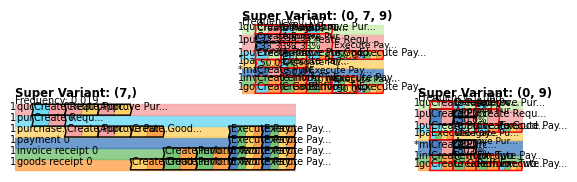

In [6]:
print(hierarchies[0], str([0]))
SVH.explore_hierarchy_top_down(final_super_variants[0][0])

In [7]:
print(hierarchies[0][0])

{2: ([(<Super_Variant_Definition.SuperVariant object at 0x126332950>, (<Super_Variant_Definition.SuperVariant object at 0x1270fe790>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x1275683d0>, (<Super_Variant_Definition.SuperVariant object at 0x12710a110>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x12710a290>, None, None)))], 8), 1: ([(<Super_Variant_Definition.SuperVariant object at 0x1275aaa50>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x127116590>, (<Super_Variant_Definition.SuperVariant object at 0x126c53390>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x125faadd0>, None, None))], 2), 0: ([(<Super_Variant_Definition.SuperVariant object at 0x126c94f90>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x1275aaa50>, None, None), (<Super_Variant_Definition.SuperVariant object at 0x1275ab950>, None, None)], 0)}
